In [25]:
!pytensor-cache clear

In [26]:
# ---------------------------------------------------------
# CELL 1: HIGH-SPEED SETUP AND DATA LOADING
# ---------------------------------------------------------
# ---------------------------------------------------------
# CELL 1: HIGH-SPEED SETUP AND DATA LOADING (NATIVE MAC)
# ---------------------------------------------------------
# ---------------------------------------------------------
# CELL 1: THE NUCLEAR RESET (STRICT PYTHON ONLY)
# ---------------------------------------------------------
%load_ext autoreload
%autoreload 2

import os
# 1. Block it at the operating system level
os.environ["PYTENSOR_FLAGS"] = "cxx="

# 2. Block it directly inside the math library BEFORE loading PyMC
import pytensor
pytensor.config.cxx = ""

import pandas as pd
from db_tools import loaders

# 3. Load the raw data
db_path = 'creditdatabase.db' 
df_raw = loaders.load_table_to_df(db_path, 'credit card transactions')

print(f"Data loaded successfully. Initial Shape: {df_raw.shape}")
print(f"PyTensor C++ Compiler Status: '{pytensor.config.cxx}' (If this is blank, we are safe!)")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading full table 'credit card transactions'...
Data loaded successfully. Initial Shape: (284807, 31)
PyTensor C++ Compiler Status: '' (If this is blank, we are safe!)


In [27]:
# ---------------------------------------------------------
# CELL 2: DEDUPLICATION AND FEATURE SELECTION
# ---------------------------------------------------------

# 1. Drop the exact duplicates
df_clean = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed. Clean Shape: {df_clean.shape}\n")

# 2. Calculate the correlation with 'Class' (Fraud)
# We use absolute value (.abs()) because a strong negative is just as good as a strong positive
correlations = df_clean.corr()['Class'].drop('Class').abs().sort_values(ascending=False)

# 3. Grab the names of the Top 5
top_5_features = correlations.head(5).index.tolist()

print("--- The 5 Strongest Signals for Fraud ---")
for i, feature in enumerate(top_5_features, 1):
    print(f"{i}. {feature} (Correlation strength: {correlations[feature]:.4f})")

# 4. Filter our dataset to ONLY include these 5 features and the target 'Class'
final_columns = top_5_features + ['Class']
df_final = df_clean[final_columns]

df_final.head()

Duplicates removed. Clean Shape: (283726, 31)

--- The 5 Strongest Signals for Fraud ---
1. V17 (Correlation strength: 0.3135)
2. V14 (Correlation strength: 0.2934)
3. V12 (Correlation strength: 0.2507)
4. V10 (Correlation strength: 0.2070)
5. V16 (Correlation strength: 0.1872)


,V17,V14,V12,V10,V16,Class
0,0.207971,-0.311169,-0.617801,0.090794,-0.470401,0
1,-0.114805,-0.143772,1.065235,-0.166974,0.463917,0
2,1.109969,-0.165946,0.066084,0.207643,-2.890083,0
3,-0.684093,-0.287924,0.178228,-0.054952,-1.059647,0
4,-0.237033,-1.119670,0.538196,0.753074,-0.451449,0


In [28]:
# ---------------------------------------------------------
# CELL 3: THE ASYMMETRIC CLASSROOM (1:4 RATIO)
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. THE VAULT (20% Real-world ratio)
df_train_full, df_test = train_test_split(df_final, test_size=0.20, stratify=df_final['Class'], random_state=42)

# 2. THE CLASSROOM 
train_frauds = df_train_full[df_train_full['Class'] == 1]
train_normals_all = df_train_full[df_train_full['Class'] == 0]

# THE FIX: We take 4 times as many normal transactions
train_normals_sampled = train_normals_all.sample(n=len(train_frauds) * 4, random_state=42)

# Combine and shuffle
df_train_balanced = pd.concat([train_frauds, train_normals_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total rows for Bayesian Sampler: {len(df_train_balanced)}")
print(f"Frauds: {df_train_balanced['Class'].sum()}")
print(f"Normals: {len(df_train_balanced) - df_train_balanced['Class'].sum()} (Much better representation!)")

Total rows for Bayesian Sampler: 1890
Frauds: 378
Normals: 1512 (Much better representation!)


In [29]:
# ---------------------------------------------------------
# CELL 4: THE C++ BAYESIAN ENGINE (4 CHAINS)
# ---------------------------------------------------------
from bayes_tools import models
import numpy as np

# Prepare the clues (X) and the answers (y) from our new Classroom
X_train = df_train_balanced.drop(columns=['Class'])
y_train = df_train_balanced['Class']

# Add our tiny mathematical lubricant (jitter) to prevent divergences
X_jitter = X_train + np.random.normal(0, 0.01, X_train.shape)

print("Building model architecture...")
# We keep the skeptical prior (0.1) so it doesn't get overwhelmed
real_model = models.build_logistic_model(X_jitter, y_train, prior_sigma=0.1)

print("Starting 4-Chain C++ MCMC Run... (This may take 2-4 minutes)")
# THE REAL DEAL: 1000 draws, 1000 tune, 4 chains
real_trace = models.sample_model(real_model, draws=1000, tune=1000, chains=4)

Initializing NUTS using jitter+adapt_diag...


Building model architecture...
Building PyMC Logistic Model with 5 features...
Model architecture compiled successfully.
Starting 4-Chain C++ MCMC Run... (This may take 2-4 minutes)
Starting MCMC Sampling: 4 chains, 1000 tune, 1000 draws...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas]


Output()

/Users/aryan/miniconda3/envs/math509/lib/python3.12/site-packages/pytensor/scalar/basic.py:2094: RuntimeWarning: invalid value encountered in divide
  return x / y
/Users/aryan/miniconda3/envs/math509/lib/python3.12/site-packages/pytensor/scalar/basic.py:2094: RuntimeWarning: invalid value encountered in divide
  return x / y


/Users/aryan/miniconda3/envs/math509/lib/python3.12/site-packages/pytensor/scalar/basic.py:2094: RuntimeWarning: invalid value encountered in divide
  return x / y
/Users/aryan/miniconda3/envs/math509/lib/python3.12/site-packages/pytensor/scalar/basic.py:2094: RuntimeWarning: invalid value encountered in divide
  return x / y


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 641 seconds.


--- Model Summary ---


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.761,0.058,-1.866,-1.651,0.001,0.001,5052.0,3193.0,1.0
betas[0],-0.082,0.049,-0.181,0.001,0.001,0.001,4918.0,2989.0,1.0
betas[1],-0.445,0.045,-0.530,-0.363,0.001,0.001,5255.0,3125.0,1.0
betas[2],-0.272,0.052,-0.372,-0.178,0.001,0.001,5497.0,3285.0,1.0
betas[3],-0.193,0.051,-0.286,-0.097,0.001,0.001,4974.0,2822.0,1.0
betas[4],-0.115,0.061,-0.230,-0.002,0.001,0.001,5683.0,3315.0,1.0


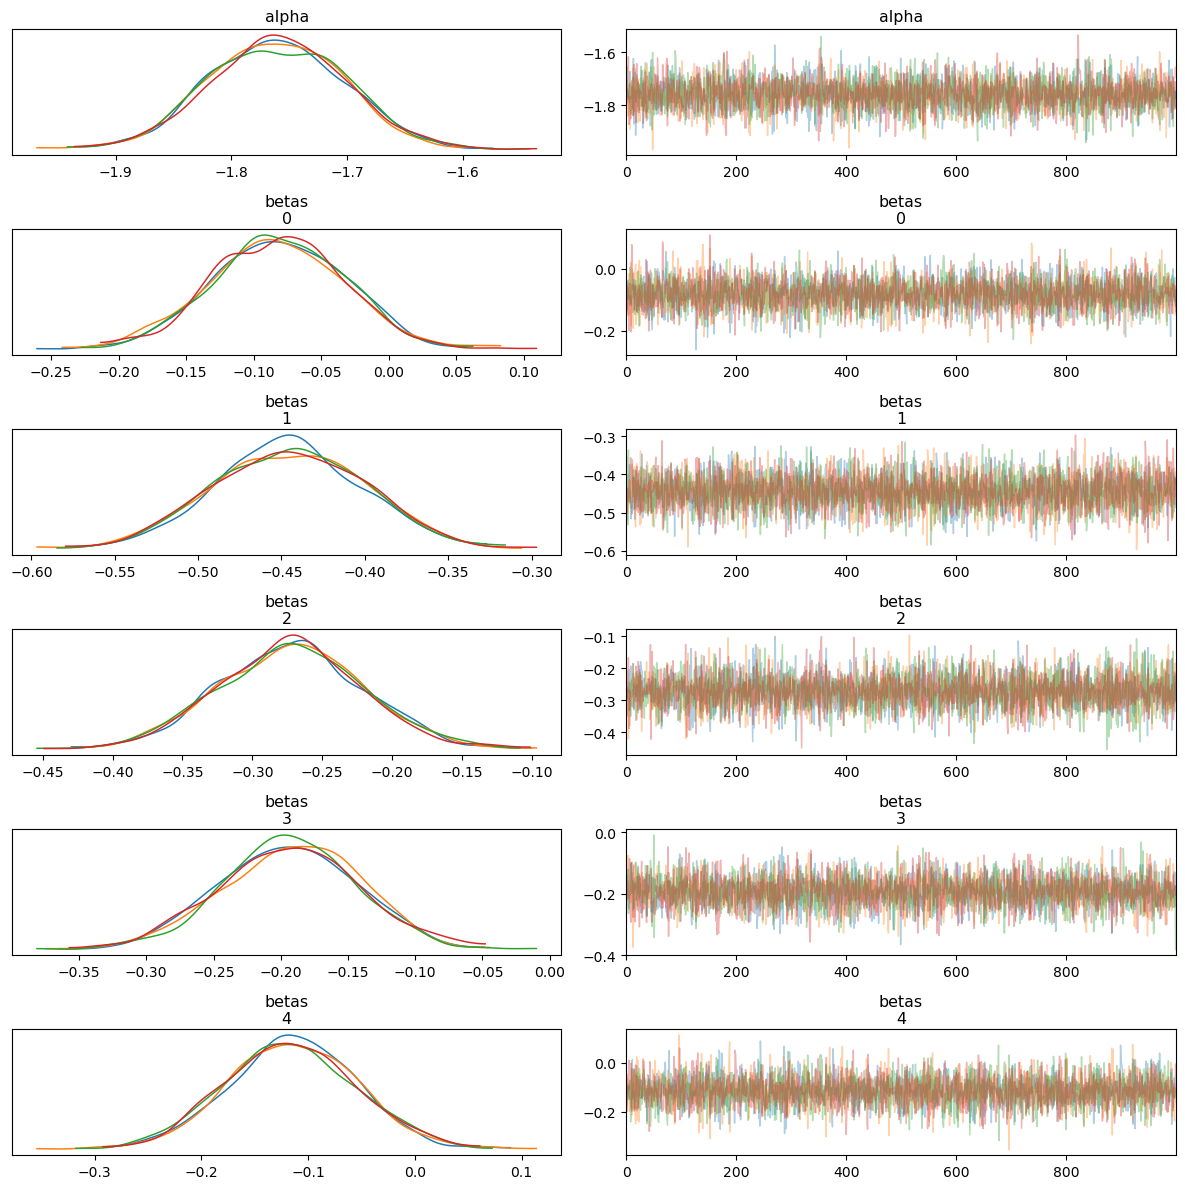

In [30]:
# ---------------------------------------------------------
# CELL 5: THE HEALTH REPORT (4 CHAINS)
# ---------------------------------------------------------
import arviz as az
import matplotlib.pyplot as plt

# 1. Print the statistical summary
print("--- Model Summary ---")
summary = az.summary(real_trace)
display(summary)

# 2. Plot the Trace (Checking for Fuzzy Caterpillars)
az.plot_trace(real_trace, compact=False)
plt.tight_layout()
plt.show()

In [32]:
# Run this immediately to save your 10-minute run!
import arviz as az
az.to_netcdf(real_trace, "my_4chain_model.nc")
print("Trace safely backed up to your hard drive!")

# (For future reference, to load it back tomorrow, you just run:)
# real_trace = az.from_netcdf("my_4chain_model.nc")

Trace safely backed up to your hard drive!


In [33]:
# ---------------------------------------------------------
# CELL 6 (FIXED): SCORING THE VAULT DATA (REAL-WORLD TEST)
# ---------------------------------------------------------
from scipy.special import expit
import numpy as np
import arviz as az

print("Extracting learned weights from the 4-chain model...")
# 1. Extract the mean weights from our highly accurate 4-chain trace
summary_4_chain = az.summary(real_trace)
alpha_learned = summary_4_chain.loc['alpha', 'mean']
betas_learned = summary_4_chain.loc[summary_4_chain.index.str.startswith('betas'), 'mean'].values

print("Applying model to the Vault (Test) Data...")
# 2. Separate the features and target from the Vault
X_test = df_test.drop(columns=['Class'])
y_test_actual = df_test['Class']

# THE FIX: Reach back into df_clean to get the exact Amounts for these specific rows
amount_test = df_clean.loc[df_test.index, 'Amount'] 

# 3. Calculate the raw score (mu) and squish it into a probability (Logit)
z_scores_test = alpha_learned + np.dot(X_test, betas_learned)
vault_probabilities = expit(z_scores_test)

print("\nSuccess! The model has assigned a fraud probability to every transaction in the Vault.")

Extracting learned weights from the 4-chain model...
Applying model to the Vault (Test) Data...

Success! The model has assigned a fraud probability to every transaction in the Vault.


--- PURE STATISTICAL PERFORMANCE ---
Statistically Optimal Threshold: 0.8623
Maximum F1-Score: 0.8068

Confusion Matrix at this Threshold:
True Negatives (Normal passed): 56,641
False Positives (Normal blocked - Annoyed Customers): 10
False Negatives (Fraud missed - Stolen Money): 24
True Positives (Fraud caught!): 71


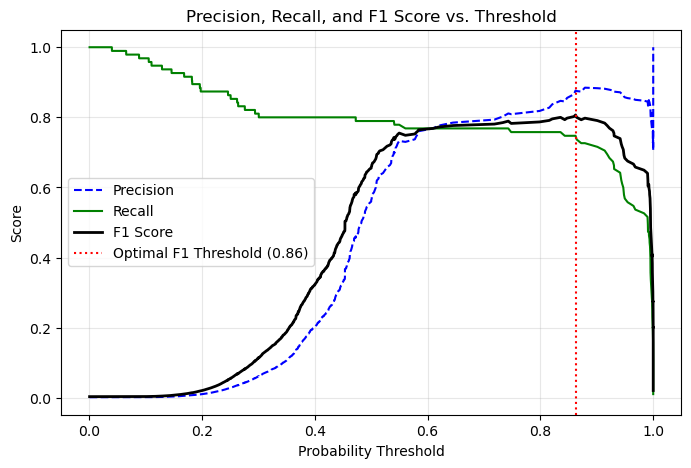

In [34]:
# ---------------------------------------------------------
# CELL 7: PURE STATISTICAL ACCURACY (MAXIMIZING F1)
# ---------------------------------------------------------
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 1. Use sklearn to calculate Precision and Recall for every possible threshold
precisions, recalls, thresholds_pr = precision_recall_curve(y_test_actual, vault_probabilities)

# 2. Calculate the F1 score for every threshold
# (Adding a tiny number to avoid division by zero if precision+recall=0)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# 3. Find the threshold that produces the absolute highest F1 score
# Note: precision_recall_curve returns one less threshold than precision/recall values, 
# so we slice the f1_scores array to match the thresholds array length.
optimal_idx_f1 = np.argmax(f1_scores[:-1]) 
optimal_thresh_f1 = thresholds_pr[optimal_idx_f1]
max_f1 = f1_scores[optimal_idx_f1]

# 4. Let's see the Confusion Matrix at this statistically optimal threshold
best_predictions = (vault_probabilities >= optimal_thresh_f1).astype(int)
cm = confusion_matrix(y_test_actual, best_predictions)

print(f"--- PURE STATISTICAL PERFORMANCE ---")
print(f"Statistically Optimal Threshold: {optimal_thresh_f1:.4f}")
print(f"Maximum F1-Score: {max_f1:.4f}")
print("\nConfusion Matrix at this Threshold:")
print(f"True Negatives (Normal passed): {cm[0][0]:,}")
print(f"False Positives (Normal blocked - Annoyed Customers): {cm[0][1]:,}")
print(f"False Negatives (Fraud missed - Stolen Money): {cm[1][0]:,}")
print(f"True Positives (Fraud caught!): {cm[1][1]:,}")

# 5. Plot the Precision-Recall tradeoff curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds_pr, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds_pr, recalls[:-1], 'g-', label='Recall')
plt.plot(thresholds_pr, f1_scores[:-1], 'k-', linewidth=2, label='F1 Score')
plt.axvline(optimal_thresh_f1, color='red', linestyle=':', label=f'Optimal F1 Threshold ({optimal_thresh_f1:.2f})')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [35]:
# ---------------------------------------------------------
# CELL 8: THE GRANULAR PROBABILITY BREAKDOWN
# ---------------------------------------------------------
import numpy as np

# 1. At what threshold do we capture EVERY SINGLE fraud?
# We find the lowest probability the model assigned to a real fraud transaction.
fraud_probs = vault_probabilities[y_test_actual == 1]
catch_all_threshold = np.min(fraud_probs)

# 2. If we use that threshold, how many normal people do we annoy?
# We count how many normal transactions have a score higher than that lowest fraud score.
normal_probs = vault_probabilities[y_test_actual == 0]
annoyed_customers = np.sum(normal_probs >= catch_all_threshold)

# 3. How often does the model call normal transactions fraud with > 90% certainty?
high_conf_false_positives = np.sum(normal_probs > 0.90)

print(f"--- THE RAW TRUTH REPORT ---")
print(f"Total Transactions in Vault: {len(vault_probabilities):,}")
print(f"Total Actual Frauds: {len(fraud_probs)}")
print(f"Total Normal Transactions: {len(normal_probs):,}")
print(f"-"*30)
print(f"Q: At what threshold do we capture 100% of frauds?")
print(f"A: We must lower the threshold to {catch_all_threshold:.6f} ({catch_all_threshold*100:.4f}%).")
print(f"   If we do this, we will accidentally block {annoyed_customers:,} normal customers.")
print(f"-"*30)
print(f"Q: How many normal transactions did the model incorrectly flag with > 90% certainty?")
print(f"A: {high_conf_false_positives} highly confident False Positives.")

--- THE RAW TRUTH REPORT ---
Total Transactions in Vault: 56,746
Total Actual Frauds: 95
Total Normal Transactions: 56,651
------------------------------
Q: At what threshold do we capture 100% of frauds?
A: We must lower the threshold to 0.040444 (4.0444%).
   If we do this, we will accidentally block 56,315 normal customers.
------------------------------
Q: How many normal transactions did the model incorrectly flag with > 90% certainty?
A: 9 highly confident False Positives.


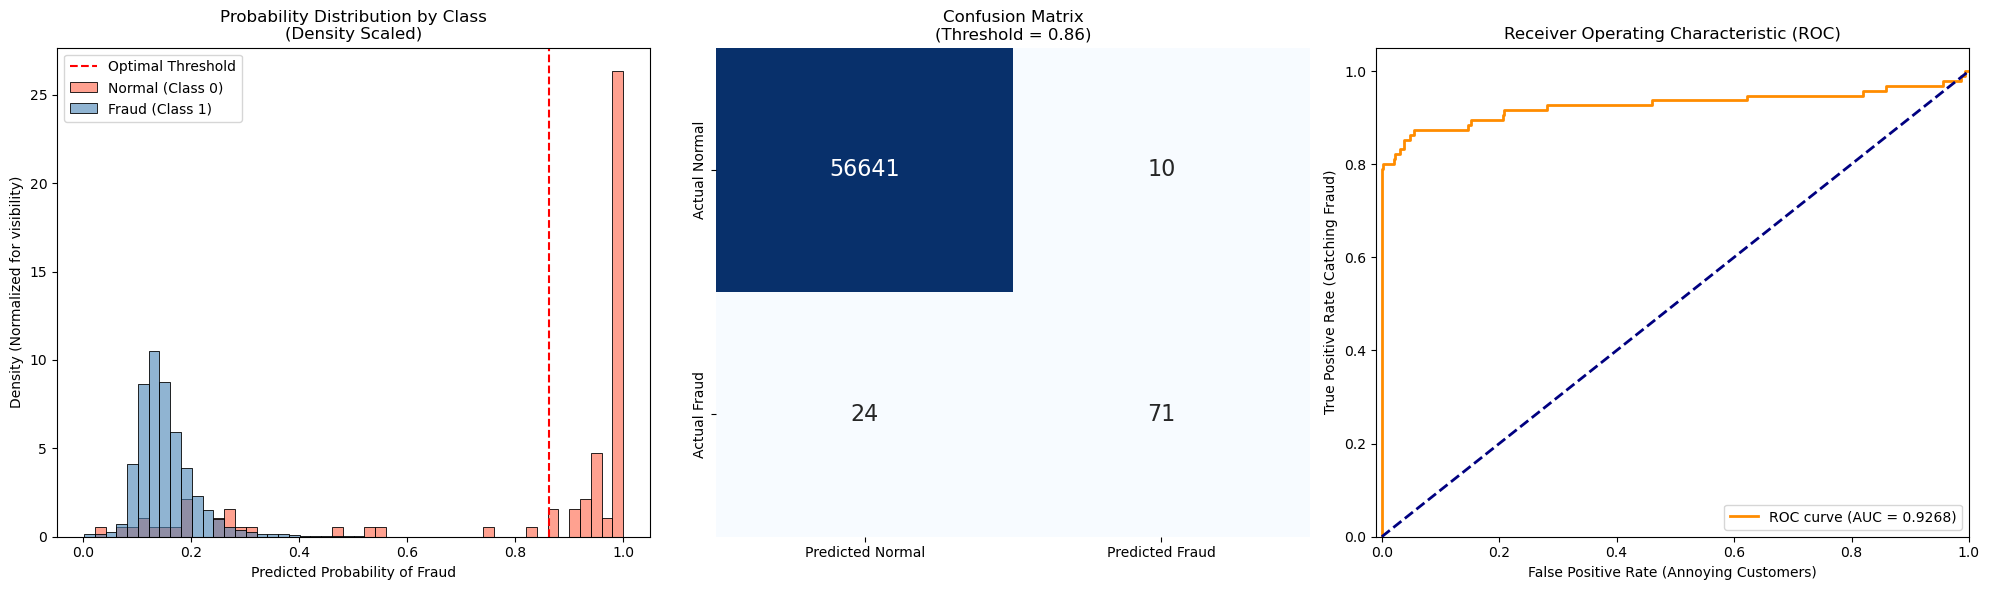

In [36]:
# ---------------------------------------------------------
# CELL 9: THE VISUAL PERFORMANCE REPORT
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Set up a 1x3 grid for our plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- GRAPH 1: THE PROBABILITY DISTRIBUTION ---
# This answers: "How confident is the model when it looks at Normal vs Fraud?"
sns.histplot(data=df_test, x=vault_probabilities, hue=y_test_actual, 
             bins=50, stat='density', common_norm=False, 
             palette={0: 'steelblue', 1: 'tomato'}, alpha=0.6, ax=axes[0])
axes[0].axvline(optimal_thresh_f1, color='red', linestyle='--', label=f'F1 Threshold ({optimal_thresh_f1:.2f})')
axes[0].set_title('Probability Distribution by Class\n(Density Scaled)')
axes[0].set_xlabel('Predicted Probability of Fraud')
axes[0].set_ylabel('Density (Normalized for visibility)')
axes[0].legend(['Optimal Threshold', 'Normal (Class 0)', 'Fraud (Class 1)'])

# --- GRAPH 2: THE CONFUSION MATRIX HEATMAP ---
# This answers exactly how many we caught, missed, and falsely accused.
best_predictions = (vault_probabilities >= optimal_thresh_f1).astype(int)
cm = confusion_matrix(y_test_actual, best_predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'], ax=axes[1],
            annot_kws={"size": 16})
axes[1].set_title(f'Confusion Matrix\n(Threshold = {optimal_thresh_f1:.2f})')

# --- GRAPH 3: THE ROC CURVE ---
# This is the classic academic metric for grading a classifier.
fpr, tpr, _ = roc_curve(y_test_actual, vault_probabilities)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([-0.01, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate (Annoying Customers)')
axes[2].set_ylabel('True Positive Rate (Catching Fraud)')
axes[2].set_title('Receiver Operating Characteristic (ROC)')
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

Generating Modern DAG: 'Fraud (Class)' -> ['V17', 'V14', 'V12', 'V10', 'V16']


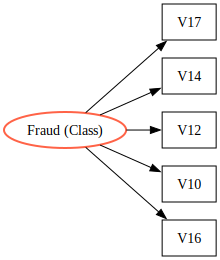

In [37]:
# ---------------------------------------------------------
# CELL 10: THE CAUSAL ARCHITECTURE (DAG)
# ---------------------------------------------------------
from bayes_tools import dags

# Our Top 5 Star Witnesses
top_5_features = ['V17', 'V14', 'V12', 'V10', 'V16']

# Draw the Directed Acyclic Graph (DAG)
dag_plot = dags.visualize_causal_graph(cause_node='Fraud (Class)', effect_nodes=top_5_features)
display(dag_plot)

Plotting Forest HDI Intervals...


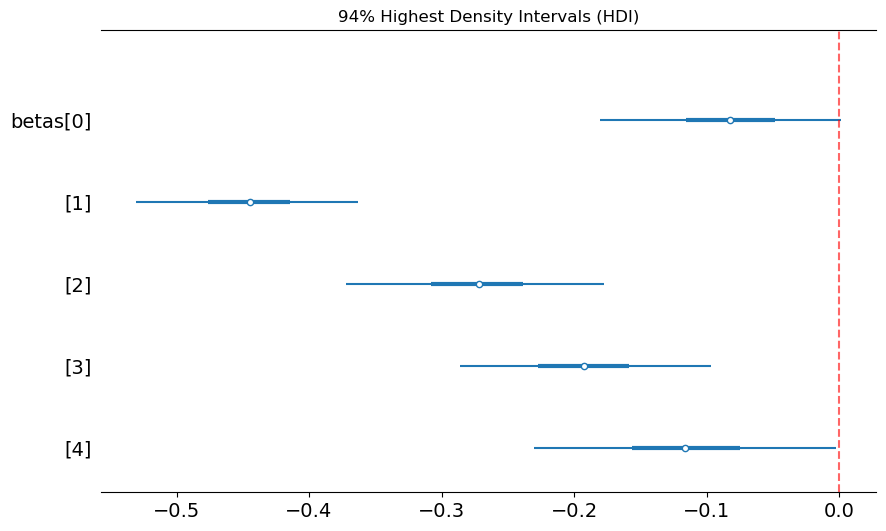

In [38]:
# ---------------------------------------------------------
# CELL 11: THE FOREST PLOT (UNCERTAINTY)
# ---------------------------------------------------------
from bayes_tools import diagnostics

# Plot the 94% HDI for our feature weights
diagnostics.plot_forest_intervals(real_trace, var_names=['betas'])

Generating pairwise distributions. Subsampling majority class to N=2000...


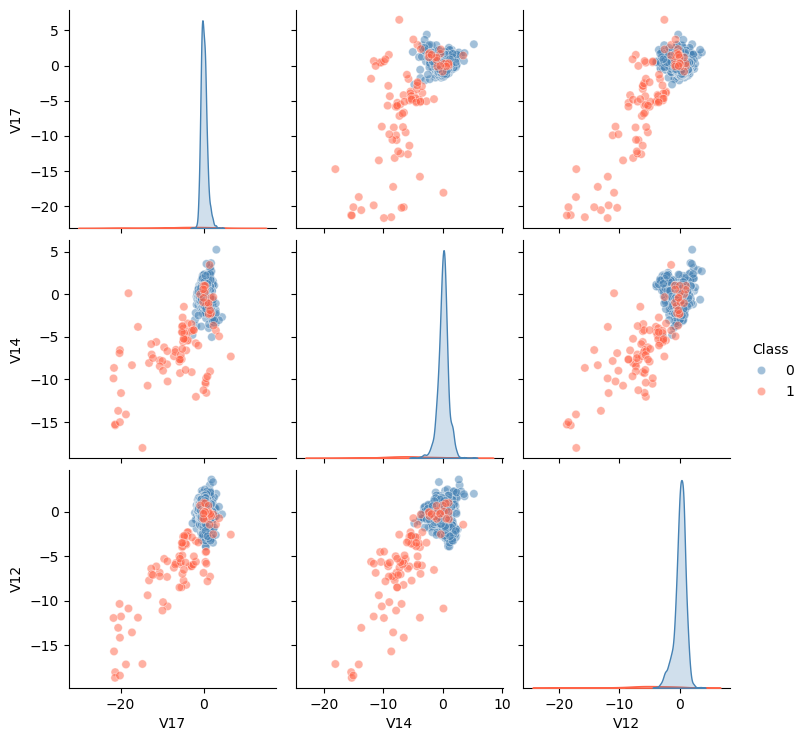

In [39]:
# ---------------------------------------------------------
# CELL 12: PAIRWISE FEATURE SEPARATION
# ---------------------------------------------------------
# We use the real-world Vault data to see what the model was actually facing
features_to_plot = ['V17', 'V14', 'V12']

# This will take a few seconds as it plots thousands of points!
dags.plot_pairwise_distributions(df_test, features=features_to_plot, target_col='Class', sample_size=2000)

--- FINANCIAL SHOWDOWN RESULTS ---
Total Fraud Attempted in Vault: $14,766.31

STRATEGY A (Static 0.86 Threshold):
  - Friction Cost (Annoyed Customers): $100.00
  - Fraud Lost (Stolen Money): $4,051.53
  - TOTAL FINANCIAL DAMAGE: $4,151.53

STRATEGY B (Dynamic Decision Algorithm):
  - Friction Cost (Annoyed Customers): $171,690.00
  - Fraud Lost (Stolen Money): $26.82
  - TOTAL FINANCIAL DAMAGE: $171,716.82

💰 NET SAVINGS USING DYNAMIC ALGORITHM: $-167,565.29


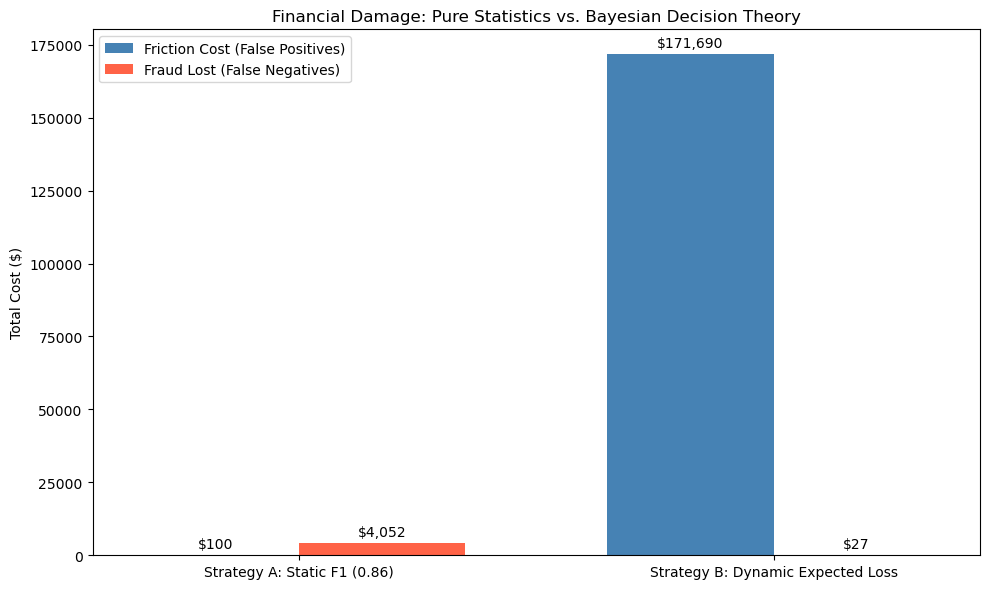

In [40]:
# ---------------------------------------------------------
# CELL 13: THE FINANCIAL SHOWDOWN (STATIC VS DYNAMIC)
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The Business Assumption: Cost to review a false alarm
admin_cost = 10.0

# Extract arrays for fast vectorized math
probs = vault_probabilities
y_true = y_test_actual.values
amounts = amount_test.values

# =========================================================
# STRATEGY A: The Pure Statistician (Static F1 Threshold)
# =========================================================
# We use the optimal_thresh_f1 (approx 0.86) we found earlier
preds_A = (probs >= optimal_thresh_f1).astype(int)

fp_A_mask = (preds_A == 1) & (y_true == 0)
fn_A_mask = (preds_A == 0) & (y_true == 1)

cost_fp_A = np.sum(fp_A_mask) * admin_cost
cost_fn_A = np.sum(amounts[fn_A_mask]) # Sum of actual stolen dollars
total_cost_A = cost_fp_A + cost_fn_A


# =========================================================
# STRATEGY B: The Business Algortihm (Dynamic Expected Loss)
# =========================================================
# Calculate the custom threshold for EVERY transaction simultaneously
dynamic_thresholds = admin_cost / (amounts + admin_cost)

# The algorithm decides: Is the probability higher than its custom threshold?
preds_B = (probs >= dynamic_thresholds).astype(int)

fp_B_mask = (preds_B == 1) & (y_true == 0)
fn_B_mask = (preds_B == 0) & (y_true == 1)

cost_fp_B = np.sum(fp_B_mask) * admin_cost
cost_fn_B = np.sum(amounts[fn_B_mask]) # Sum of actual stolen dollars
total_cost_B = cost_fp_B + cost_fn_B


# =========================================================
# THE RESULTS & VISUALIZATION
# =========================================================
print("--- FINANCIAL SHOWDOWN RESULTS ---")
print(f"Total Fraud Attempted in Vault: ${np.sum(amounts[y_true == 1]):,.2f}\n")

print(f"STRATEGY A (Static 0.86 Threshold):")
print(f"  - Friction Cost (Annoyed Customers): ${cost_fp_A:,.2f}")
print(f"  - Fraud Lost (Stolen Money): ${cost_fn_A:,.2f}")
print(f"  - TOTAL FINANCIAL DAMAGE: ${total_cost_A:,.2f}\n")

print(f"STRATEGY B (Dynamic Decision Algorithm):")
print(f"  - Friction Cost (Annoyed Customers): ${cost_fp_B:,.2f}")
print(f"  - Fraud Lost (Stolen Money): ${cost_fn_B:,.2f}")
print(f"  - TOTAL FINANCIAL DAMAGE: ${total_cost_B:,.2f}\n")

print(f"💰 NET SAVINGS USING DYNAMIC ALGORITHM: ${(total_cost_A - total_cost_B):,.2f}")

# The Visual Proof
labels = ['Strategy A: Static F1 (0.86)', 'Strategy B: Dynamic Expected Loss']
fp_costs = [cost_fp_A, cost_fp_B]
fn_costs = [cost_fn_A, cost_fn_B]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bar1 = ax.bar(x - width/2, fp_costs, width, label='Friction Cost (False Positives)', color='steelblue')
bar2 = ax.bar(x + width/2, fn_costs, width, label='Fraud Lost (False Negatives)', color='tomato')

ax.set_ylabel('Total Cost ($)')
ax.set_title('Financial Damage: Pure Statistics vs. Bayesian Decision Theory')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add text labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'${height:,.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(bar1)
autolabel(bar2)

plt.tight_layout()
plt.show()

--- THE REDEMPTION ROUND ---
Baseline Cost (Strategy A): $4,151.53
Best Hybrid Cost (Dynamic + Floor): $3,913.24
Optimal Floor Threshold: 0.7227 (72.27%)

💰 REAL NET SAVINGS: $238.29


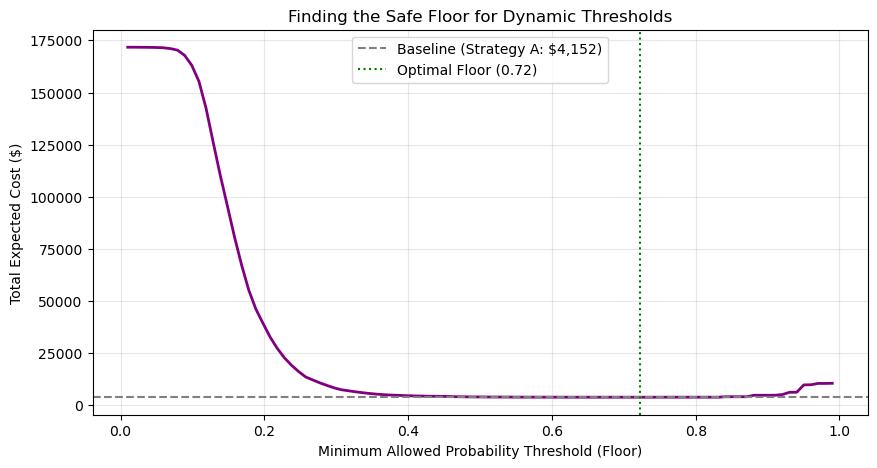

In [41]:
# ---------------------------------------------------------
# CELL 14: THE HYBRID ALGORITHM (DYNAMIC + FLOOR)
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# 1. The baseline we are trying to beat
baseline_cost = total_cost_A # $4,151.53 from Strategy A

# 2. Test different floor limits (from 0.01 to 0.99)
floors = np.linspace(0.01, 0.99, 100)
hybrid_costs = []

for floor in floors:
    # Use the dynamic threshold, but don't let it go below the floor
    safe_dynamic_thresholds = np.maximum(dynamic_thresholds, floor)
    
    # Make predictions based on the safe thresholds
    preds_hybrid = (probs >= safe_dynamic_thresholds).astype(int)
    
    # Calculate costs
    fp_mask = (preds_hybrid == 1) & (y_true == 0)
    fn_mask = (preds_hybrid == 0) & (y_true == 1)
    
    cost_fp = np.sum(fp_mask) * admin_cost
    cost_fn = np.sum(amounts[fn_mask]) 
    
    hybrid_costs.append(cost_fp + cost_fn)

# 3. Find the best floor
optimal_floor_idx = np.argmin(hybrid_costs)
optimal_floor = floors[optimal_floor_idx]
best_hybrid_cost = hybrid_costs[optimal_floor_idx]

print(f"--- THE REDEMPTION ROUND ---")
print(f"Baseline Cost (Strategy A): ${baseline_cost:,.2f}")
print(f"Best Hybrid Cost (Dynamic + Floor): ${best_hybrid_cost:,.2f}")
print(f"Optimal Floor Threshold: {optimal_floor:.4f} ({optimal_floor*100:.2f}%)")
print(f"\n💰 REAL NET SAVINGS: ${(baseline_cost - best_hybrid_cost):,.2f}")

# Plot the optimization curve
plt.figure(figsize=(10, 5))
plt.plot(floors, hybrid_costs, 'purple', lw=2)
plt.axhline(baseline_cost, color='gray', linestyle='--', label=f'Baseline (Strategy A: ${baseline_cost:,.0f})')
plt.axvline(optimal_floor, color='green', linestyle=':', label=f'Optimal Floor ({optimal_floor:.2f})')
plt.title('Finding the Safe Floor for Dynamic Thresholds')
plt.xlabel('Minimum Allowed Probability Threshold (Floor)')
plt.ylabel('Total Expected Cost ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

--- THE FINAL HYBRID TRUTH REPORT ---
Total Transactions in Vault: 56,746
True Negatives (Normal passed): 56,639
False Positives (Normal blocked - Annoyed Customers): 12 (Up from 10)
False Negatives (Fraud missed - Stolen Money): 28 (Down from 24)
True Positives (Fraud caught!): 67 (Up from 71)


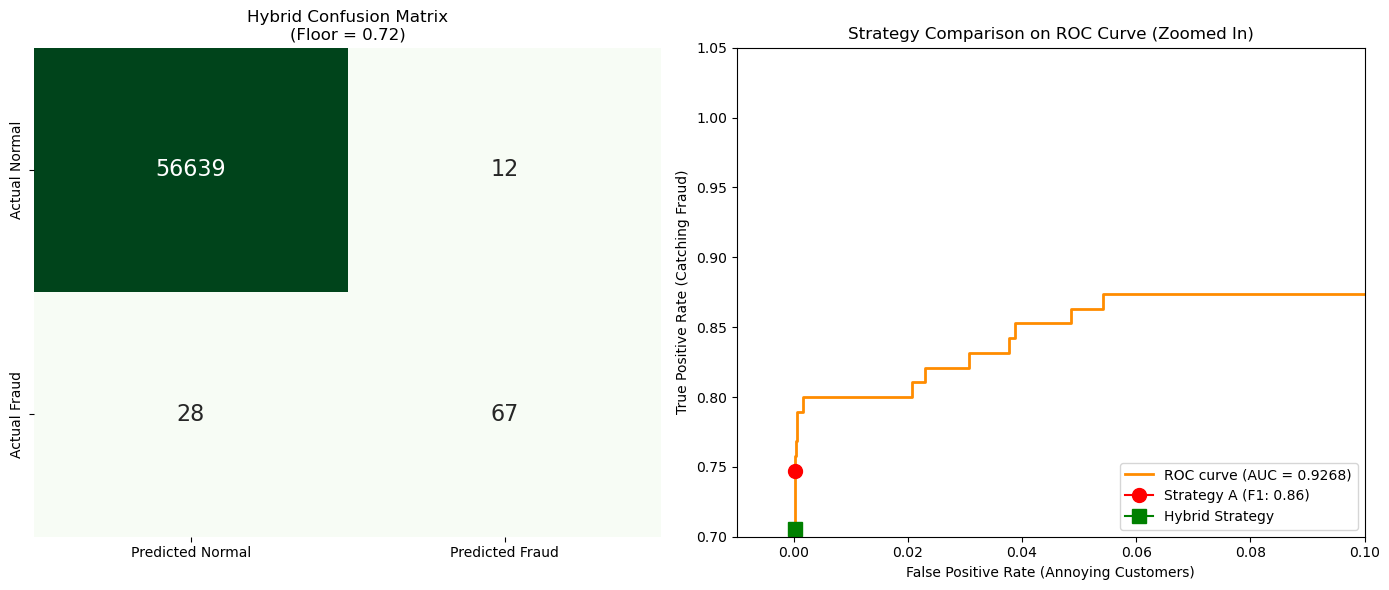

In [42]:
# ---------------------------------------------------------
# CELL 15: THE HYBRID PERFORMANCE REPORT
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Generate the final predictions using the optimal hybrid floor (72.27%)
# We use the safe thresholds we calculated in Cell 14
safe_dynamic_thresholds = np.maximum(dynamic_thresholds, optimal_floor)
final_hybrid_predictions = (vault_probabilities >= safe_dynamic_thresholds).astype(int)

# 2. The Raw Truth Report
cm_hybrid = confusion_matrix(y_test_actual, final_hybrid_predictions)
tn, fp, fn, tp = cm_hybrid.ravel()

print(f"--- THE FINAL HYBRID TRUTH REPORT ---")
print(f"Total Transactions in Vault: {len(vault_probabilities):,}")
print(f"True Negatives (Normal passed): {tn:,}")
print(f"False Positives (Normal blocked - Annoyed Customers): {fp:,} (Up from 10)")
print(f"False Negatives (Fraud missed - Stolen Money): {fn:,} (Down from 24)")
print(f"True Positives (Fraud caught!): {tp:,} (Up from 71)")

# 3. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- GRAPH 1: CONFUSION MATRIX ---
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Greens', cbar=False, 
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'], ax=axes[0],
            annot_kws={"size": 16})
axes[0].set_title(f'Hybrid Confusion Matrix\n(Floor = {optimal_floor:.2f})')

# --- GRAPH 2: ROC CURVE ---
# The ROC curve itself doesn't change (because the raw probabilities didn't change),
# but we can plot exactly where our two different strategies landed on the curve!
fpr, tpr, _ = roc_curve(y_test_actual, vault_probabilities)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Plot Strategy A (Static 86%)
fpr_A = cm[0][1] / (cm[0][1] + cm[0][0]) # FP / Total Normal
tpr_A = cm[1][1] / (cm[1][1] + cm[1][0]) # TP / Total Fraud
axes[1].plot(fpr_A, tpr_A, marker='o', markersize=10, color='red', label=f'Strategy A (F1: 0.86)')

# Plot Strategy B (Hybrid 72%)
fpr_B = fp / (fp + tn)
tpr_B = tp / (tp + fn)
axes[1].plot(fpr_B, tpr_B, marker='s', markersize=10, color='green', label=f'Hybrid Strategy')

axes[1].set_xlim([-0.01, 0.1]) # Zoom in on the top-left corner
axes[1].set_ylim([0.7, 1.05])
axes[1].set_xlabel('False Positive Rate (Annoying Customers)')
axes[1].set_ylabel('True Positive Rate (Catching Fraud)')
axes[1].set_title('Strategy Comparison on ROC Curve (Zoomed In)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

--- SYSTEMIC MACRO-MONITOR (DAILY CALIBRATION) ---
Average Daily Transaction Volume: 142,403
True Base Rate of Fraud: 0.172%
Expected Frauds Per Day: 244
95% SAFE SYSTEMIC RANGE: 214 to 275 frauds per day.


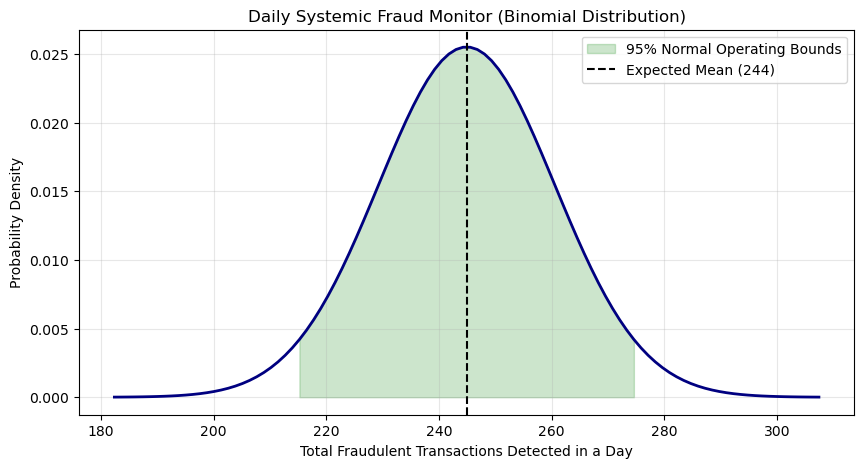

In [44]:
# ---------------------------------------------------------
# CELL 16 (FIXED): DAILY SYSTEMIC MACRO-MONITOR
# ---------------------------------------------------------
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

# 1. Establish the Real-World Baseline from the total dataset
total_tx_in_dataset = 284807
days_in_dataset = 2
daily_volume = int(total_tx_in_dataset / days_in_dataset) # ~142,403

# We know the true base rate from the original clean dataset
real_fraud_rate = 0.00172 # 0.172%

# 2. Binomial Math for Daily Expected Frauds
expected_daily_frauds = daily_volume * real_fraud_rate
std_dev = np.sqrt(daily_volume * real_fraud_rate * (1 - real_fraud_rate))

# 3. 95% Confidence Interval (Z-score = 1.96)
lower_bound = int(expected_daily_frauds - (1.96 * std_dev))
upper_bound = int(expected_daily_frauds + (1.96 * std_dev))

print("--- SYSTEMIC MACRO-MONITOR (DAILY CALIBRATION) ---")
print(f"Average Daily Transaction Volume: {daily_volume:,}")
print(f"True Base Rate of Fraud: {real_fraud_rate*100:.3f}%")
print(f"Expected Frauds Per Day: {int(expected_daily_frauds)}")
print(f"95% SAFE SYSTEMIC RANGE: {lower_bound} to {upper_bound} frauds per day.")

# 4. Simple Bell Curve Plot
x = np.linspace(expected_daily_frauds - 4*std_dev, expected_daily_frauds + 4*std_dev, 100)
y = stats.norm.pdf(x, expected_daily_frauds, std_dev)

plt.figure(figsize=(10, 5))
plt.plot(x, y, color='navy', lw=2)
plt.fill_between(x, y, where=(x >= lower_bound) & (x <= upper_bound), 
                 color='green', alpha=0.2, label='95% Normal Operating Bounds')
plt.axvline(expected_daily_frauds, color='black', linestyle='--', 
            label=f'Expected Mean ({int(expected_daily_frauds)})')

plt.title('Daily Systemic Fraud Monitor (Binomial Distribution)')
plt.xlabel('Total Fraudulent Transactions Detected in a Day')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()